Found 1698 images belonging to 2 classes.
Found 424 images belonging to 2 classes.


C:\Users\noorf\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.7485 - loss: 0.5830 - val_accuracy: 0.7972 - val_loss: 0.5010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.8698 - loss: 0.3357 - val_accuracy: 0.8656 - val_loss: 0.3337
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.9111 - loss: 0.3071 - val_accuracy: 0.9340 - val_loss: 0.1861
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.9311 - loss: 0.2275 - val_accuracy: 0.9434 - val_loss: 0.1339
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.9435 - loss: 0.1763 - val_accuracy: 0.9481 - val_loss: 0.1296
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.9582 - loss: 0.1618 - val_accuracy: 0.9623 - val_loss: 0.1216
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.9759 - loss: 0.0880 - val_accuracy: 0.9764 - val_loss: 0.0566
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9711 - loss: 0.1277 - val_accuracy: 0.9764 - v

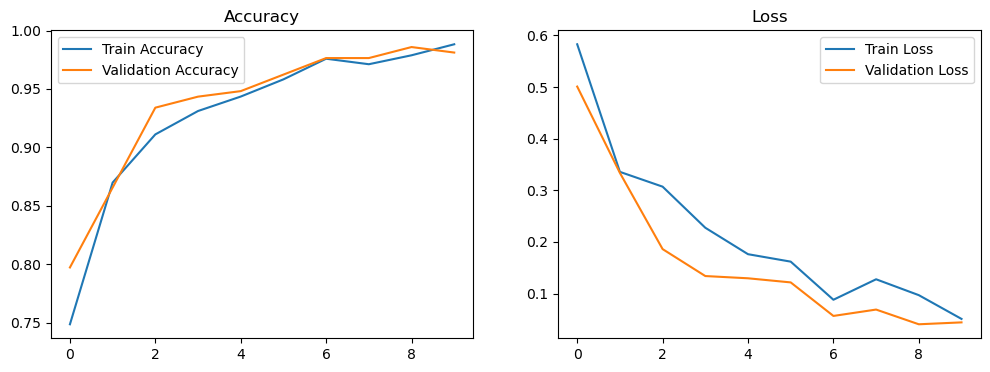

In [ ]:
# =========================================
# Leaf Disease Detection using CNN
# Dataset: PlantVillage
# Framework: TensorFlow / Keras
# =========================================

import tensorflow as tf # type: ignore
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras.preprocessing import image # type: ignore
import matplotlib.pyplot as plt # type: ignore
import numpy as np # type: ignore

# ===============================
# 1. Parameters
# ===============================
DATASET_PATH = "PlantVillage"   # <-- change this path
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# ===============================
# 2. Data Preprocessing
# ===============================
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

NUM_CLASSES = train_data.num_classes

# ===============================
# 3. Build CNN Model
# ===============================
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# ===============================
# 4. Compile Model
# ===============================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ===============================
# 5. Train Model
# ===============================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

# ===============================
# 6. Plot Accuracy & Loss
# ===============================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

# ===============================
# 7. Save Model
# ===============================
model.save("leaf_disease_cnn_model.h5")

# ===============================
# 8. Predict on New Image
# ===============================
def predict_leaf(image_path):
    img = image.load_img(image_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    class_names = list(train_data.class_indices.keys())
    predicted_class = class_names[np.argmax(prediction)]

    print("Predicted Disease:", predicted_class)

# Example:
# predict_leaf("test_leaf.jpg")